<a href="https://colab.research.google.com/github/Traton08/HW1/blob/main/COVID_Project_Final_Submission_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Mortality Prediction — End-to-End Data Science Workflow
This notebook covers:
- Part 1: Descriptive Analytics (EDA)
- Part 2: Predictive Modeling (Logistic, Tree, Random Forest, XGBoost, MLP)
- Part 3: Explainability (SHAP)
- Saving models/plots for the Streamlit app


In [21]:
!pip -q install scikit-learn==1.4.2 joblib==1.4.2 xgboost==2.1.0 pandas==2.2.2 numpy==1.26.4

In [22]:
import os
os.makedirs("reports", exist_ok=True)

## Part 1 — Descriptive Analytics (EDA)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download dataset (from instructor-provided Google Drive file id)
file_id = '1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE'
download_url = f'https://drive.google.com/uc?export=download&id={file_id}'
!wget -q -O covid.csv "{download_url}"

# Load raw data (drop any unwanted column)
data = pd.read_csv("covid.csv", usecols=lambda column: column not in ['Unnamed: 0'])

# Create a balanced working dataframe for modeling (5k deaths + 5k survivals)
death_1_sample = data[data['DEATH'] == 1].sample(n=5000, random_state=42)
death_0_sample = data[data['DEATH'] == 0].sample(n=5000, random_state=42)
df = pd.concat([death_1_sample, death_0_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,SEX,HOSPITALIZED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,IMMUNOSUPPRESSION,HYPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,COVID_POSITIVE,DEATH
0,1,0,1,64,0,1,0,0,0,1,0,0,0,1,0,1,0
1,0,0,0,78,0,0,0,0,0,0,0,0,0,0,1,1,1
2,0,1,1,47,0,0,0,0,0,1,0,0,0,0,1,1,1
3,0,1,0,37,0,1,0,0,0,0,0,0,0,0,0,1,1
4,1,1,1,72,0,1,0,0,0,0,0,0,0,0,0,1,1


In [24]:
# Dataset overview (required)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nTarget distribution:")
print(df["DEATH"].value_counts())


Shape: (10000, 17)
Columns: ['SEX', 'HOSPITALIZED', 'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'IMMUNOSUPPRESSION', 'HYPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'COVID_POSITIVE', 'DEATH']

Target distribution:
DEATH
0    5000
1    5000
Name: count, dtype: int64


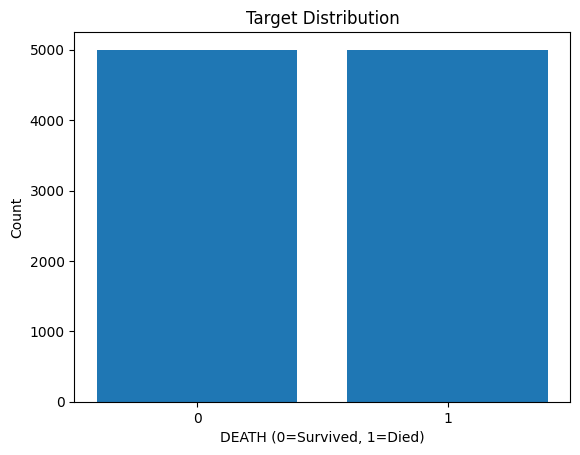

In [25]:
# 1.2 Target Distribution
counts = df["DEATH"].value_counts().sort_index()
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("DEATH (0=Survived, 1=Died)")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.savefig("reports/target_distribution.png", bbox_inches="tight")
plt.show()


### 1.3 Feature Distributions & Relationships (4+ plots)

<Figure size 640x480 with 0 Axes>

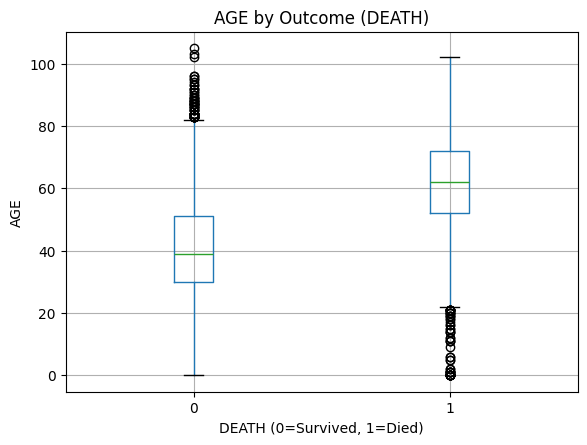

In [26]:
# Plot 1: AGE by outcome
plt.figure()
df.boxplot(column="AGE", by="DEATH")
plt.suptitle("")
plt.title("AGE by Outcome (DEATH)")
plt.xlabel("DEATH (0=Survived, 1=Died)")
plt.ylabel("AGE")
plt.savefig("reports/eda1.png", bbox_inches="tight")
plt.show()


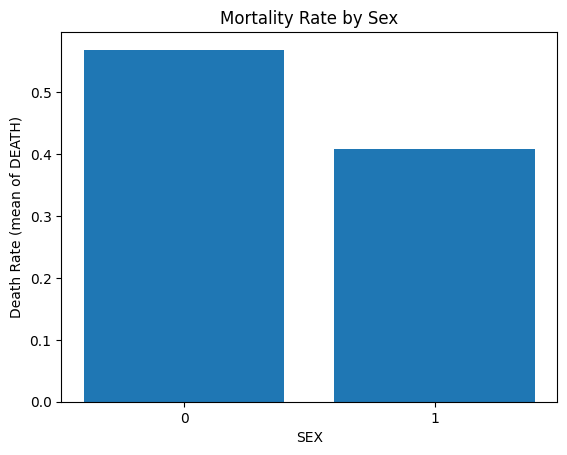

,DEATH
SEX,
0,0.568899
1,0.408520


In [27]:
# Plot 2: Mortality rate by SEX
sex_rate = df.groupby("SEX")["DEATH"].mean()
plt.figure()
plt.bar(sex_rate.index.astype(str), sex_rate.values)
plt.xlabel("SEX")
plt.ylabel("Death Rate (mean of DEATH)")
plt.title("Mortality Rate by Sex")
plt.savefig("reports/eda2.png", bbox_inches="tight")
plt.show()

sex_rate


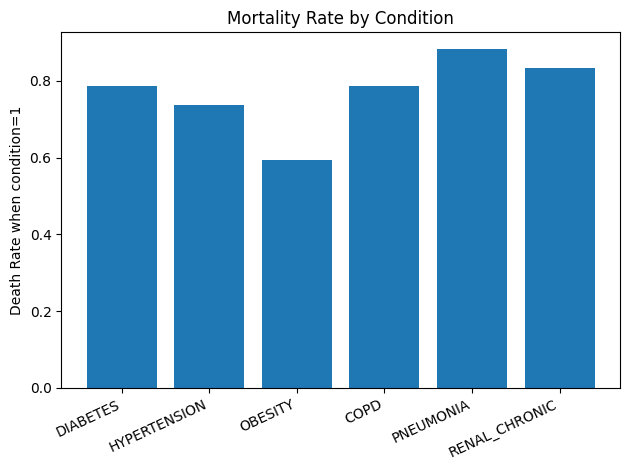

,0
PNEUMONIA,0.882441
RENAL_CHRONIC,0.833333
COPD,0.786585
DIABETES,0.786550
HYPERTENSION,0.736860
OBESITY,0.594789


In [28]:
# Plot 3: Mortality rate by selected conditions
conditions = ["DIABETES","HYPERTENSION","OBESITY","COPD","PNEUMONIA","RENAL_CHRONIC"]
rates = {c: df[df[c]==1]["DEATH"].mean() for c in conditions}

plt.figure()
plt.bar(rates.keys(), rates.values())
plt.xticks(rotation=25, ha="right")
plt.ylabel("Death Rate when condition=1")
plt.title("Mortality Rate by Condition")
plt.tight_layout()
plt.savefig("reports/eda3.png", bbox_inches="tight")
plt.show()

pd.Series(rates).sort_values(ascending=False)


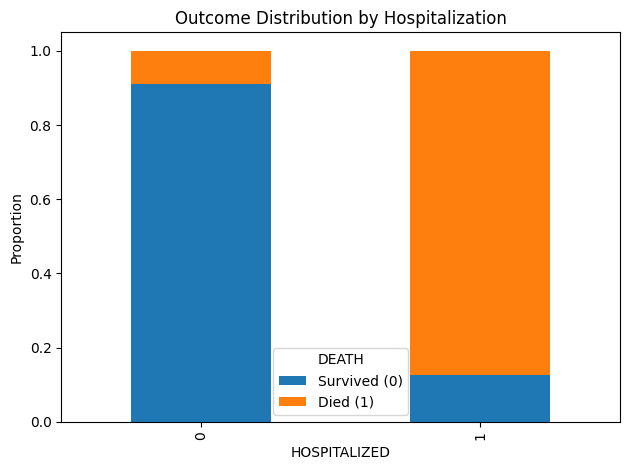

DEATH,0,1
HOSPITALIZED,,
0,0.911808,0.088192
1,0.127262,0.872738


In [29]:
# Plot 4: Outcome distribution by hospitalization (stacked proportions)
ct = pd.crosstab(df["HOSPITALIZED"], df["DEATH"], normalize="index")
ct.plot(kind="bar", stacked=True)
plt.title("Outcome Distribution by Hospitalization")
plt.xlabel("HOSPITALIZED")
plt.ylabel("Proportion")
plt.legend(title="DEATH", labels=["Survived (0)", "Died (1)"])
plt.tight_layout()
plt.savefig("reports/eda4.png", bbox_inches="tight")
plt.show()

ct


### 1.4 Correlation Heatmap

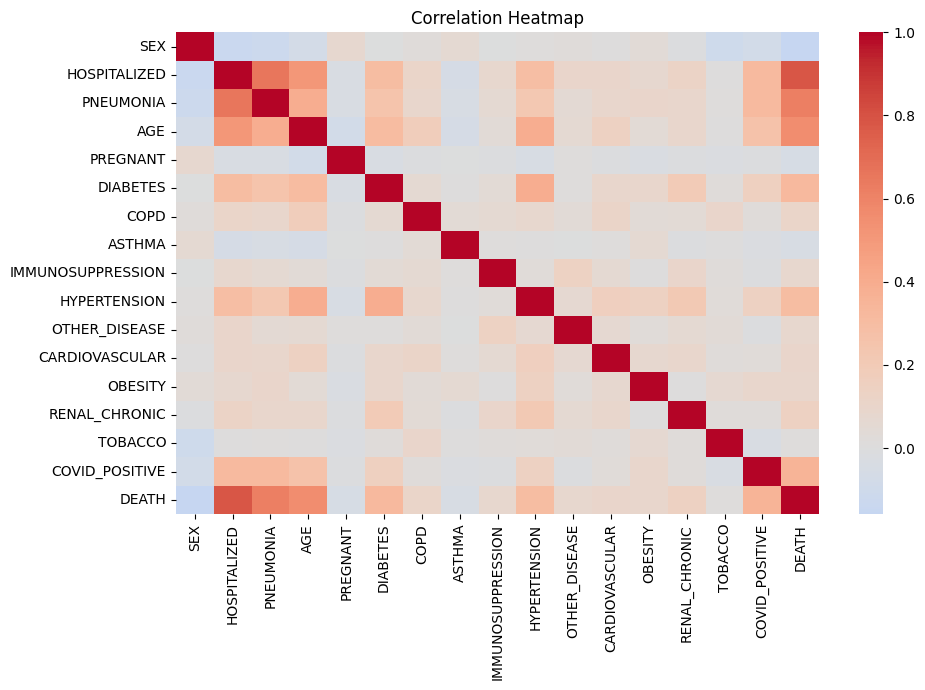

In [30]:
corr = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("reports/corr_heatmap.png", bbox_inches="tight")
plt.show()


## Part 2 — Predictive Analytics

In [31]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

RANDOM_STATE = 42

X = df.drop(columns=["DEATH"])
y = df["DEATH"].astype(int)

num_cols = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols)
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape


((7000, 16), (3000, 16))

In [32]:
def clf_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba),
    }

def plot_roc(y_true, y_proba, title):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.tight_layout()
    plt.show()


### 2.2 Logistic Regression Baseline

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [34]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

log_model.fit(X_train, y_train)

log_proba = log_model.predict_proba(X_test)[:, 1]
log_pred = (log_proba >= 0.5).astype(int)

log_results = clf_metrics(y_test, log_pred, log_proba)
log_results

{'Accuracy': 0.9093333333333333,
 'Precision': 0.8976683937823834,
 'Recall': 0.924,
 'F1': 0.9106438896189225,
 'ROC_AUC': 0.9562444444444443}

### 2.3 Decision Tree (GridSearchCV, 5-fold)

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

tree_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

tree_grid = {
    "clf__max_depth": [3, 5, 7, 10],
    "clf__min_samples_leaf": [5, 10, 20, 50]
}

tree_search = GridSearchCV(
    tree_pipe,
    tree_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

tree_search.fit(X_train, y_train)
best_tree = tree_search.best_estimator_

tree_proba = best_tree.predict_proba(X_test)[:, 1]
tree_pred = (tree_proba >= 0.5).astype(int)

tree_results = clf_metrics(y_test, tree_pred, tree_proba)
tree_search.best_params_, tree_results

({'clf__max_depth': 3, 'clf__min_samples_leaf': 50},
 {'Accuracy': 0.9123333333333333,
  'Precision': 0.8907138344914719,
  'Recall': 0.94,
  'F1': 0.9146934803762569,
  'ROC_AUC': 0.9455137777777777})

### 2.4 Random Forest (GridSearchCV, 5-fold)

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [3, 5, 8]
}

rf_search = GridSearchCV(
    rf_pipe,
    rf_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

rf_proba = best_rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)

rf_results = clf_metrics(y_test, rf_pred, rf_proba)
rf_search.best_params_, rf_results

({'clf__max_depth': 5, 'clf__n_estimators': 200},
 {'Accuracy': 0.916,
  'Precision': 0.8885429638854296,
  'Recall': 0.9513333333333334,
  'F1': 0.9188667095943336,
  'ROC_AUC': 0.9550408888888889})

### 2.5 XGBoost (GridSearchCV, 5-fold)

In [37]:
from xgboost import XGBClassifier

xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [3, 4, 5, 6],
    "clf__learning_rate": [0.01, 0.05, 0.1]
}

xgb_search = GridSearchCV(
    xgb_pipe,
    xgb_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

xgb_proba = best_xgb.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_proba >= 0.5).astype(int)

xgb_results = clf_metrics(y_test, xgb_pred, xgb_proba)
xgb_search.best_params_, xgb_results

({'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 100},
 {'Accuracy': 0.9133333333333333,
  'Precision': 0.8884711779448622,
  'Recall': 0.9453333333333334,
  'F1': 0.9160206718346253,
  'ROC_AUC': 0.9569282222222223})

### ROC Curves (required plots)

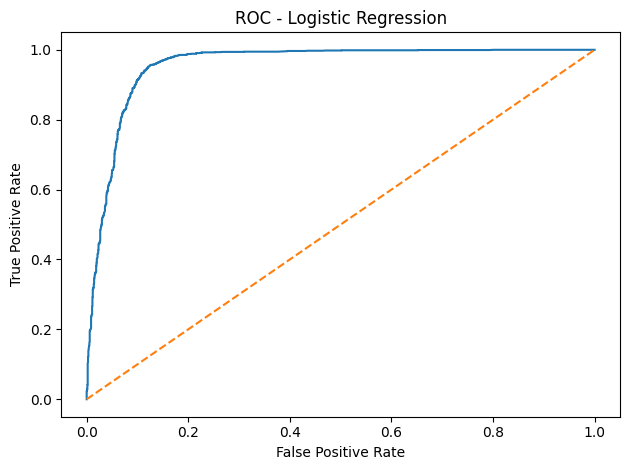

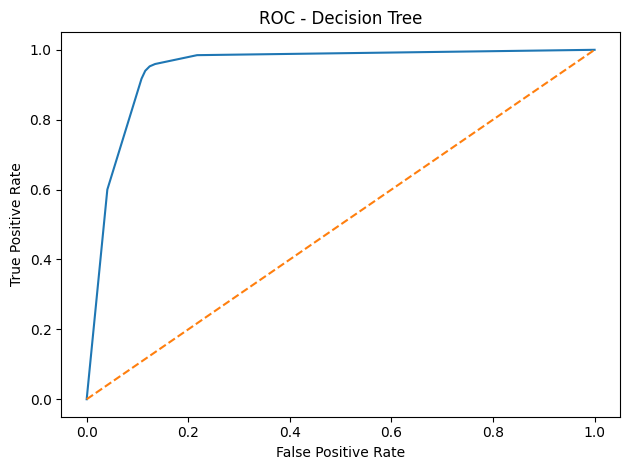

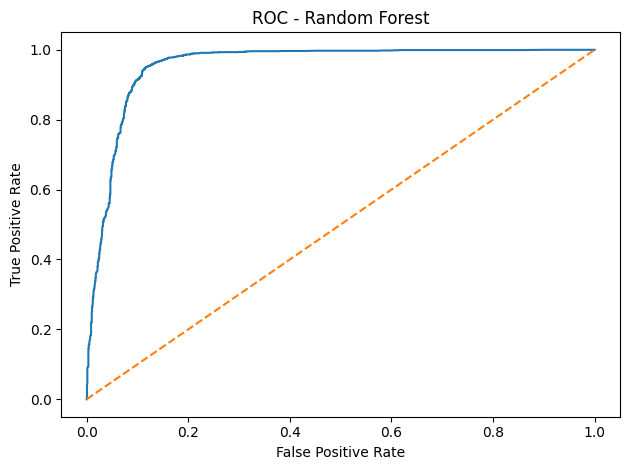

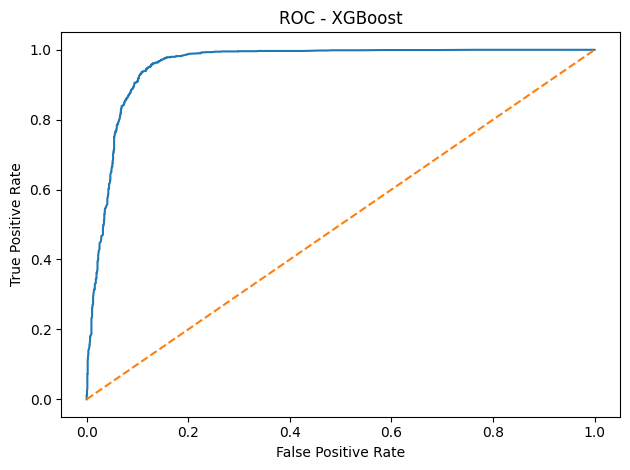

In [38]:
plot_roc(y_test, log_proba, "ROC - Logistic Regression")
plot_roc(y_test, tree_proba, "ROC - Decision Tree")
plot_roc(y_test, rf_proba, "ROC - Random Forest")
plot_roc(y_test, xgb_proba, "ROC - XGBoost")


### 2.6 Neural Network (MLP)

In [39]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt


# Fit/transform using TRAIN only
X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

tf.random.set_seed(42)
np.random.seed(42)

input_dim = X_train_p.shape[1]

mlp = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc")]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = mlp.fit(
    X_train_p, y_train.values,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# Predict + metrics (re-use your clf_metrics function)
mlp_proba = mlp.predict(X_test_p).ravel()
mlp_pred = (mlp_proba >= 0.5).astype(int)
mlp_results = clf_metrics(y_test, mlp_pred, mlp_proba)
mlp_results

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - auc: 0.7379 - loss: 0.6034 - val_auc: 0.9404 - val_loss: 0.3277
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - auc: 0.9455 - loss: 0.2989 - val_auc: 0.9445 - val_loss: 0.2866
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - auc: 0.9505 - loss: 0.2661 - val_auc: 0.9451 - val_loss: 0.2753
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.9517 - loss: 0.2570 - val_auc: 0.9455 - val_loss: 0.2707
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.9526 - loss: 0.2527 - val_auc: 0.9460 - val_loss: 0.2688
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.9538 - loss: 0.2488 - val_auc: 0.9464 - val_loss: 0.2675
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - auc: 0.9548 - loss: 0.2460 - val_auc: 0.9464 - val_loss: 0.2666
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - auc: 0.9557 - loss: 0.2437 - val_auc: 0.9465 - val_loss: 0.2659
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.9565 - loss:

{'Accuracy': 0.911,
 'Precision': 0.8879798615481435,
 'Recall': 0.9406666666666667,
 'F1': 0.9135642602784072,
 'ROC_AUC': 0.954880888888889}

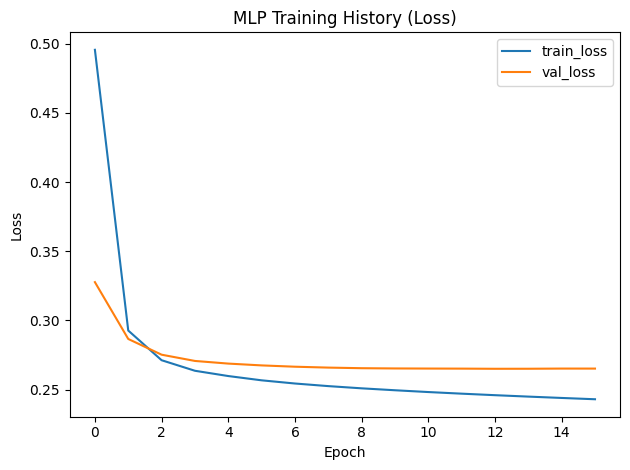

In [40]:
import os

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("MLP Training History (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/mlp_loss.png", dpi=150)
plt.show()

### 2.7 Model Comparison Summary

In [41]:
results_df = pd.DataFrame([
    {"Model": "Logistic Regression", **log_results},
    {"Model": "Decision Tree", **tree_results},
    {"Model": "Random Forest", **rf_results},
    {"Model": "XGBoost", **xgb_results},
    {"Model": "MLP (Keras)", **mlp_results},
]).sort_values("F1", ascending=False)

results_df


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Random Forest,0.916000,0.888543,0.951333,0.918867,0.955041
3,XGBoost,0.913333,0.888471,0.945333,0.916021,0.956928
1,Decision Tree,0.912333,0.890714,0.940000,0.914693,0.945514
4,MLP (Keras),0.911000,0.887980,0.940667,0.913564,0.954881
0,Logistic Regression,0.909333,0.897668,0.924000,0.910644,0.956244


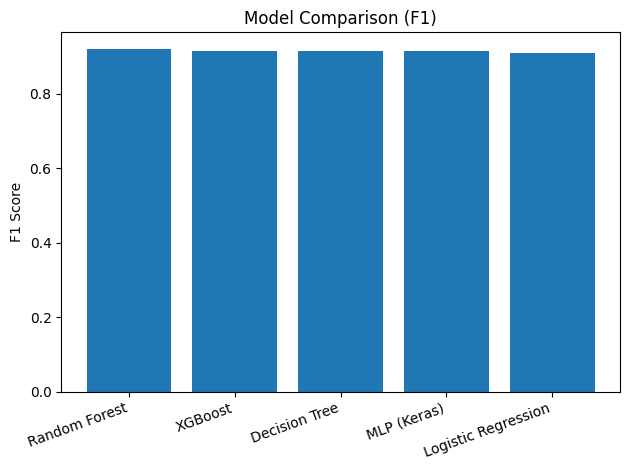

In [42]:
plt.figure()
plt.bar(results_df["Model"], results_df["F1"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("F1 Score")
plt.title("Model Comparison (F1)")
plt.tight_layout()
plt.show()


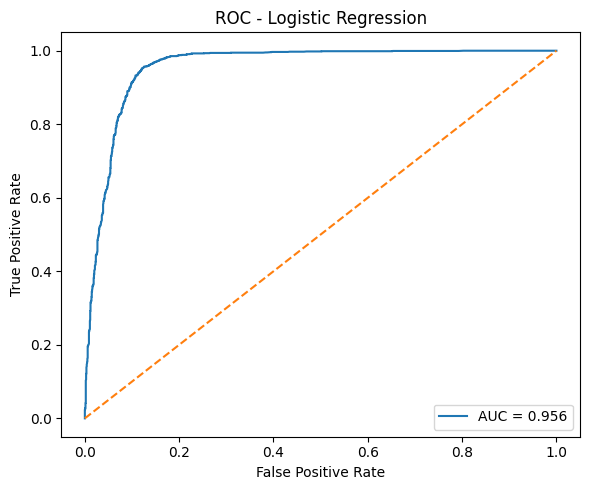

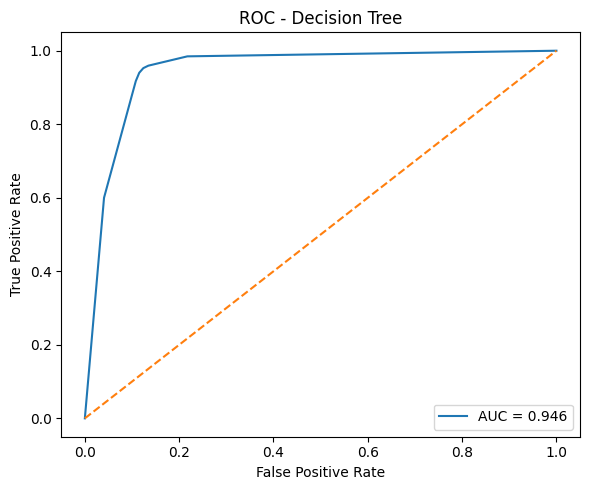

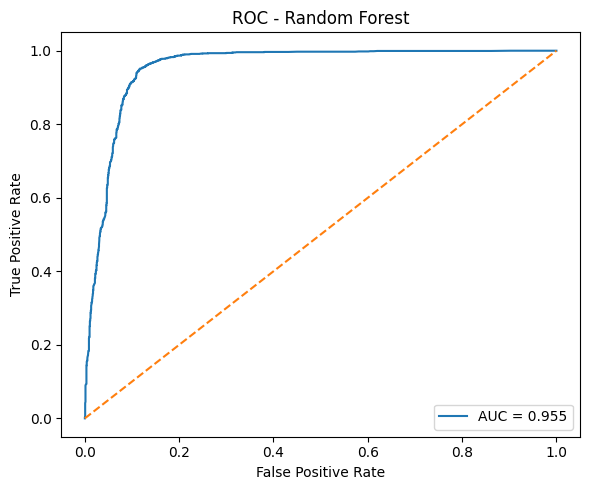

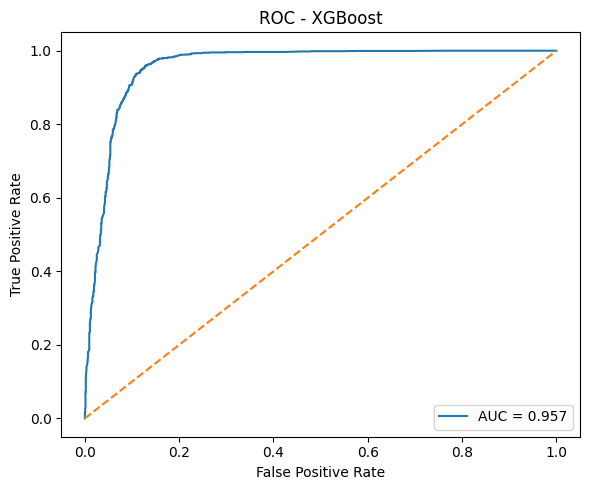

In [43]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

os.makedirs("reports", exist_ok=True)

def save_roc(model, X_test, y_test, filename, title):
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

save_roc(log_model, X_test, y_test, "reports/roc_logistic.png", "ROC - Logistic Regression")
save_roc(best_tree, X_test, y_test, "reports/roc_tree.png", "ROC - Decision Tree")
save_roc(best_rf, X_test, y_test, "reports/roc_rf.png", "ROC - Random Forest")
save_roc(best_xgb, X_test, y_test, "reports/roc_xgb.png", "ROC - XGBoost")

In [44]:
import os
print([f for f in os.listdir("reports") if f.startswith("roc_")])

['roc_tree.png', 'roc_rf.png', 'roc_xgb.png', 'roc_logistic.png']


## Part 3 — Explainability (SHAP)

In [45]:
best_tree_model = best_xgb if xgb_results["F1"] >= rf_results["F1"] else best_rf
best_tree_name = "xgb" if best_tree_model is best_xgb else "rf"
best_tree_name

'rf'

In [46]:
import os
os.makedirs("reports", exist_ok=True)


**SHAP interpretation (bullet points):**

- Top features:
- Direction of impact:
- How a decision-maker could use this:


/tmp/ipykernel_3678/2773176967.py:42: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


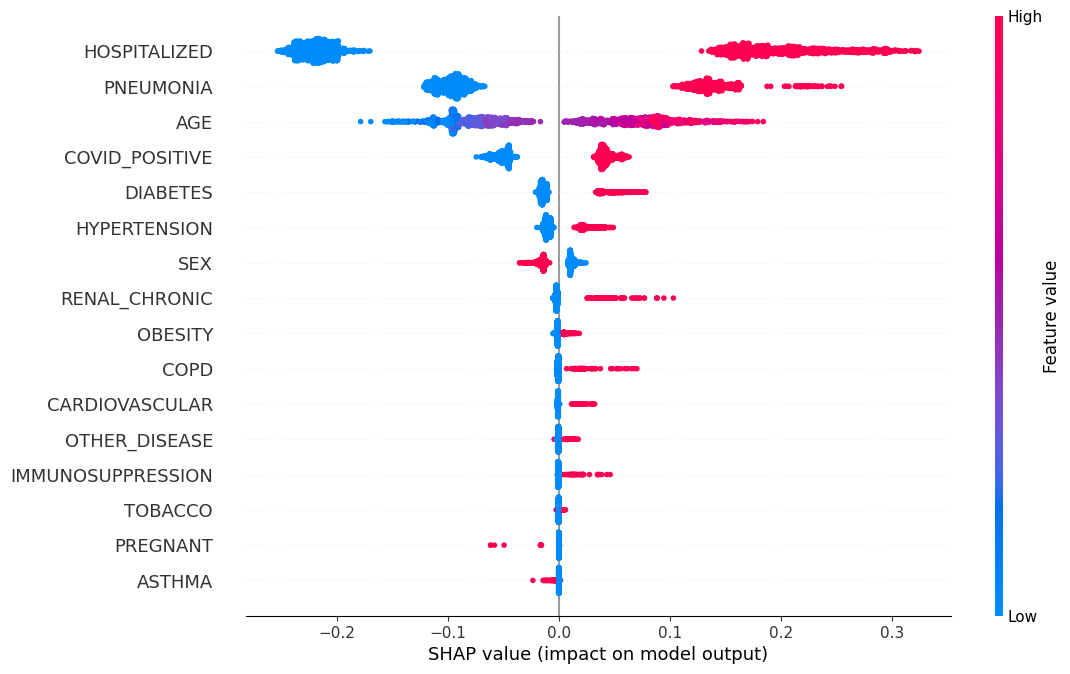

In [47]:
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

os.makedirs("reports", exist_ok=True)

# Pipeline parts
prep = best_tree_model.named_steps["prep"]
clf  = best_tree_model.named_steps["clf"]

# Transform data
X_train_t = prep.transform(X_train)
if hasattr(X_train_t, "toarray"):  # if sparse
    X_train_t = X_train_t.toarray()

feature_names = X_train.columns.tolist()

# sample for speed
rng = np.random.RandomState(42)
idx = rng.choice(X_train_t.shape[0], size=min(2000, X_train_t.shape[0]), replace=False)
X_shap = X_train_t[idx]

# Put into a DataFrame so SHAP handles feature names cleanly
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

# Explainer
explainer = shap.TreeExplainer(clf)

# IMPORTANT: use legacy shap_values list so we can cleanly select class 1
# shap_values_list = [class0, class1]
shap_values_list = explainer.shap_values(X_shap_df)

# Fix: Correctly extract SHAP values for class 1 across all samples and features
# Based on kernel state, shap_values_list is a 3D array of shape (n_samples, n_features, n_classes)
sv1 = shap_values_list[:, :, 1]  # class 1 = DEATH

# -------------------------
# 1) Beeswarm summary plot (NO clipping)
# -------------------------
shap.summary_plot(
    sv1,
    X_shap_df,
    feature_names=feature_names,
    plot_size=(14, 8),
    show=False
)
fig = plt.gcf()
fig.subplots_adjust(left=0.35, right=0.98, top=0.95, bottom=0.20)
fig.savefig(f"reports/shap_beeswarm_{best_tree_name}.png", dpi=300, bbox_inches="tight", pad_inches=0.8)
plt.show()
plt.close(fig)

/tmp/ipykernel_3678/2332735313.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


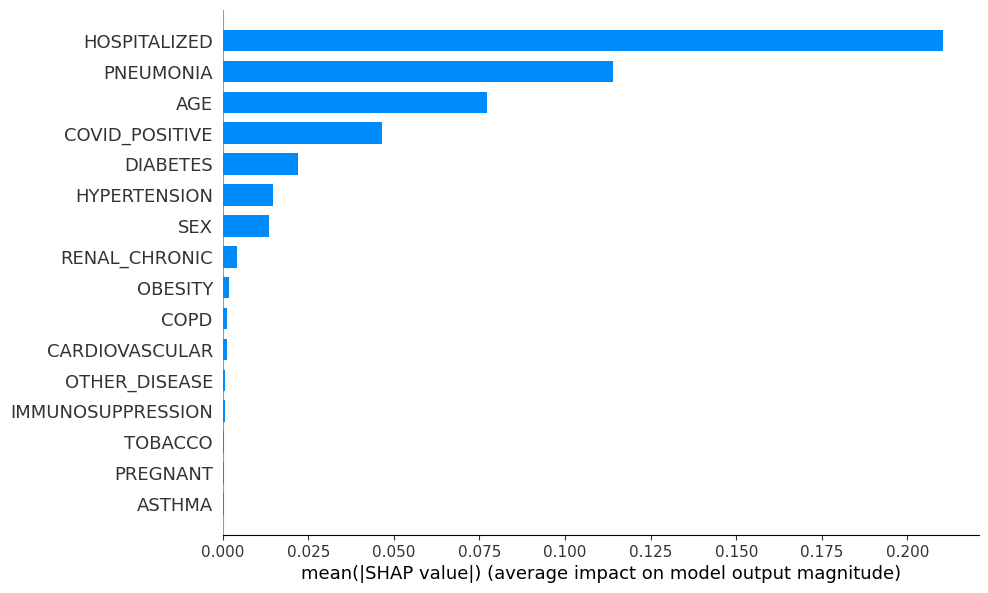

In [48]:
# 2) Bar plot (NO clipping)
shap.summary_plot(
    sv1,
    X_shap_df,
    feature_names=feature_names,
    plot_type="bar",
    plot_size=(12, 7),
    show=False
)
fig = plt.gcf()
fig.subplots_adjust(left=0.35, right=0.98, top=0.95, bottom=0.20)
fig.savefig(f"reports/shap_bar_{best_tree_name}.png", dpi=300, bbox_inches="tight", pad_inches=0.8)
plt.show()
plt.close(fig)


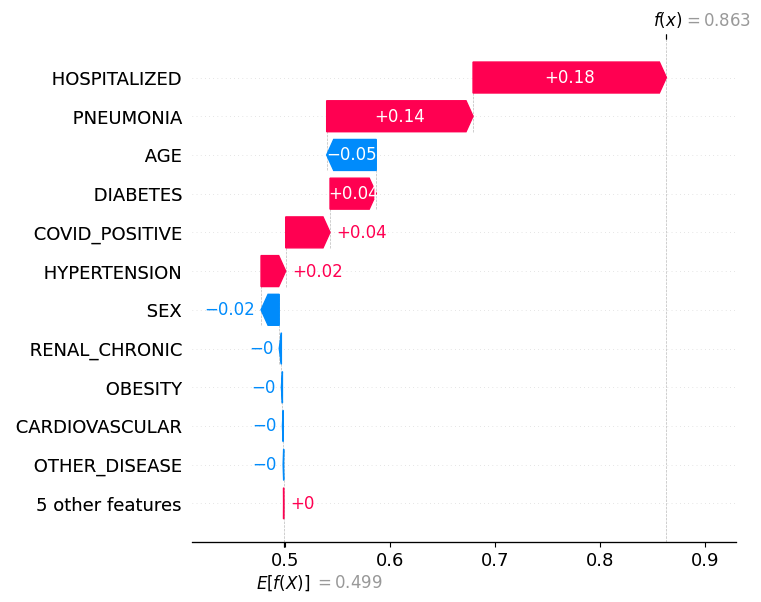

In [49]:
# 3) Waterfall (legacy, class 1) (NO clipping)

row_i = 0
plt.figure(figsize=(18, 6))
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1],   # base for class 1
    sv1[row_i],                    # SHAP values for class 1, one row
    feature_names=feature_names,
    features=X_shap_df.iloc[row_i].values,
    max_display=12,
    show=False
)
fig = plt.gcf()
fig.subplots_adjust(left=0.30, right=0.98, top=0.92, bottom=0.25)
fig.savefig(f"reports/shap_waterfall_{best_tree_name}.png", dpi=300, bbox_inches="tight", pad_inches=1.0)
plt.show()
plt.close(fig)

## Save Models & Artifacts for Streamlit Deployment

In [50]:
import os
os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)


In [51]:
import joblib

# Save pipelines (preprocessing included)
joblib.dump(log_model, "models/logistic.joblib")
joblib.dump(best_tree, "models/tree.joblib")
joblib.dump(best_rf, "models/rf.joblib")
joblib.dump(best_xgb, "models/xgb.joblib")

# Save MLP + preprocessor used for MLP inputs
mlp.save("models/mlp.keras")
joblib.dump(preprocessor, "models/preprocessor.joblib")

# Save best params too (Streamlit Tab 3)
best_params = {
    "tree": tree_search.best_params_,
    "rf": rf_search.best_params_,
    "xgb": xgb_search.best_params_
}
joblib.dump(best_params, "reports/best_params.joblib")

results_df.to_csv("reports/model_results.csv", index=False)

print("Saved: models/ and reports/ ✅")

Saved: models/ and reports/ ✅


In [52]:
import os
print("models:", os.listdir("models"))
print("reports:", os.listdir("reports"))

models: ['logistic.joblib', 'mlp.keras', 'preprocessor.joblib', 'rf.joblib', 'xgb.joblib', 'tree.joblib']
reports: ['roc_tree.png', 'eda3.png', 'corr_heatmap.png', 'roc_rf.png', 'model_results.csv', 'shap_beeswarm_rf.png', 'eda4.png', 'shap_bar_rf.png', 'mlp_loss.png', 'roc_xgb.png', 'eda2.png', 'roc_logistic.png', 'shap_waterfall_rf.png', 'eda1.png', 'target_distribution.png', 'best_params.joblib']


In [53]:
import os, joblib
os.makedirs("models", exist_ok=True)

joblib.dump(log_model, "models/logistic.joblib")
joblib.dump(best_tree, "models/tree.joblib")
joblib.dump(best_rf, "models/rf.joblib")
joblib.dump(best_xgb, "models/xgb.joblib")

print("Saved updated models:", os.listdir("models"))

Saved updated models: ['logistic.joblib', 'mlp.keras', 'preprocessor.joblib', 'rf.joblib', 'xgb.joblib', 'tree.joblib']


In [54]:
import sklearn, joblib, xgboost, numpy, pandas
print("sklearn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("xgboost:", xgboost.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)

sklearn: 1.4.2
joblib: 1.4.2
xgboost: 2.1.0
numpy: 1.26.4
pandas: 2.2.2


In [55]:
import os, joblib
os.makedirs("models", exist_ok=True)
joblib.dump(log_model, "models/logistic.joblib")
joblib.dump(best_tree, "models/tree.joblib")
joblib.dump(best_rf, "models/rf.joblib")
joblib.dump(best_xgb, "models/xgb.joblib")

['models/xgb.joblib']